In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os 

In [4]:
photo = cv2.imread("color_bird.jpg")
photo = cv2.cvtColor(photo,cv2.COLOR_BGR2RGB)

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [5]:
print(photo)

[[[253 255 254]
  [253 255 254]
  [253 255 254]
  ...
  [254 243 164]
  [254 243 164]
  [254 243 164]]

 [[253 255 254]
  [253 255 254]
  [253 255 254]
  ...
  [254 243 164]
  [254 243 164]
  [254 243 164]]

 [[253 255 254]
  [253 255 254]
  [253 255 254]
  ...
  [255 244 164]
  [255 244 164]
  [255 244 164]]

 ...

 [[ 11  29  43]
  [ 11  29  43]
  [ 12  30  44]
  ...
  [ 28  69  75]
  [ 27  68  74]
  [ 27  68  74]]

 [[ 11  29  43]
  [ 11  29  43]
  [ 11  29  43]
  ...
  [ 25  68  74]
  [ 25  68  74]
  [ 25  68  74]]

 [[ 10  28  42]
  [ 11  29  43]
  [ 11  29  43]
  ...
  [ 25  68  74]
  [ 24  67  73]
  [ 24  67  73]]]


In [6]:
pixel = photo.reshape((-1,3))
pixel = np.float32(pixel)

In [7]:
k = 4

In [8]:
when_stop = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,100,0.2)

In [9]:
Error,label,centers=cv2.kmeans(pixel,k,None,when_stop,10,cv2.KMEANS_RANDOM_CENTERS)

In [10]:
centers = np.uint8(centers)

In [11]:
compressed=centers[label.flatten()]

In [12]:
compressed=compressed.reshape(photo.shape)

In [13]:
cv2.imwrite("compressed.jpg", cv2.cvtColor(compressed,cv2.COLOR_RGB2BGR))

True

In [15]:
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

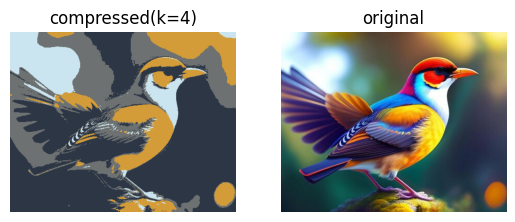

In [19]:
plt.subplot(1,2,2)
plt.title("original")
plt.imshow(photo)
plt.axis('off')

plt.subplot(1,2,1)
plt.title("compressed(k=4)")
plt.imshow(compressed)
plt.axis('off')
plt.show()